In [313]:
using DataFrames, CSV, Plots
include("/Users/johnbuckner/.julia/dev/UniversalDiffEq.jl/src/UniversalDiffEq.jl")


Main.UniversalDiffEq

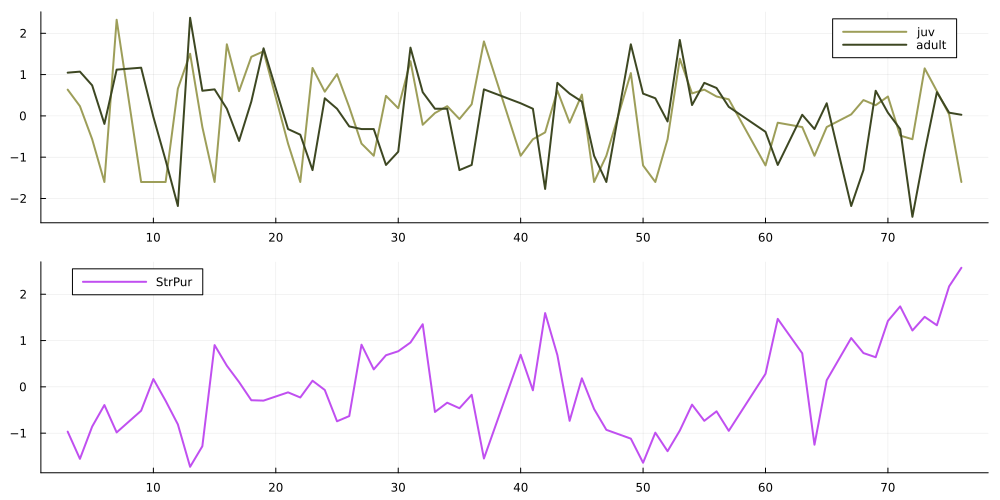

In [494]:
site = 4
dat = CSV.read("../data/processed_time_series.csv", DataFrame)[:,2:end]
dat = sort(dat,:PERIOD)

dat_states = dat[dat.SITE .== site,[:PERIOD,:MacJuv,:MacPyr]]
training = dat_states

X = dat[dat.SITE .== site,[:PERIOD,:StrPur,:PycHel]]



p1 = Plots.plot(training.PERIOD, training.MacJuv, label = "juv", width = 2, color = "#9d9e59" )
Plots.plot!(training.PERIOD, training.MacPyr, label = "adult", width = 2, color = "#3d4722")
#Plots.plot!(testing.PERIOD, testing.MacJuv, label = "juv testing", width = 1.5, linestyle = :dash, color = "#9d9e59")
#Plots.plot!(testing.PERIOD, testing.MacPyr, label = "adult training", width = 1.5,linestyle = :dash, color = "#3d4722")
p2 = Plots.plot(X.PERIOD, X.StrPur, label = "StrPur", width = 2, color = "#c04ff0" )
plot(p1,p2, layout = (2,1), size = (1000,500))

In [495]:
X[1:2,:]

Row,PERIOD,StrPur,PycHel
,Int64,Float64,Float64
1,3,-0.966806,-0.74234
2,4,-1.55477,-0.74234


In [496]:
include("/Users/johnbuckner/github/UDEsWithSpatialReplicates/analysis/models/UDE.jl")

init (generic function with 1 method)

In [497]:
covars = [1,2]
model, training! = init(training,X,covars, 0.5, 50,site)
training!(model)
nothing

[1.73088225186961, 0.697266387413689]262


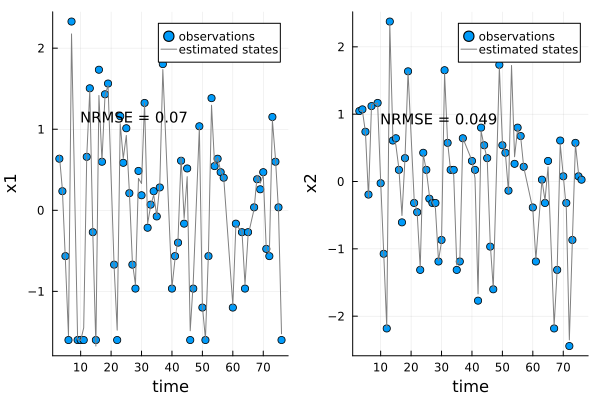

In [498]:
UniversalDiffEq.plot_state_estimates(model)

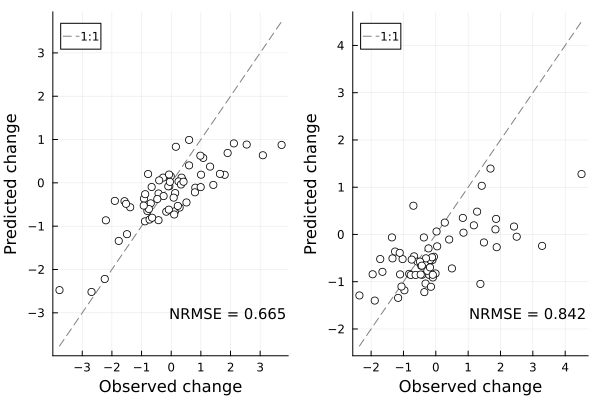

In [499]:
UniversalDiffEq.plot_predictions(model)

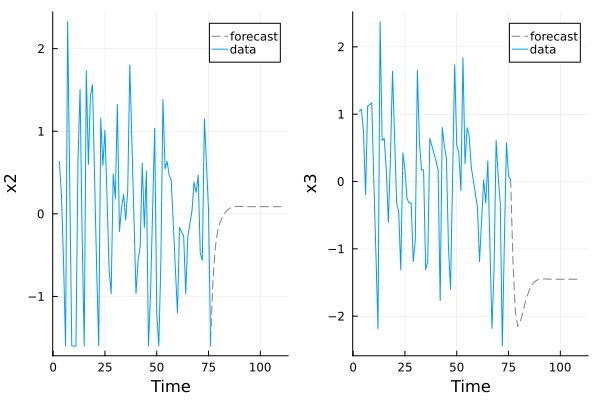

In [500]:
plt,(p1,p2)=UniversalDiffEq.plot_forecast(model,30)
plt

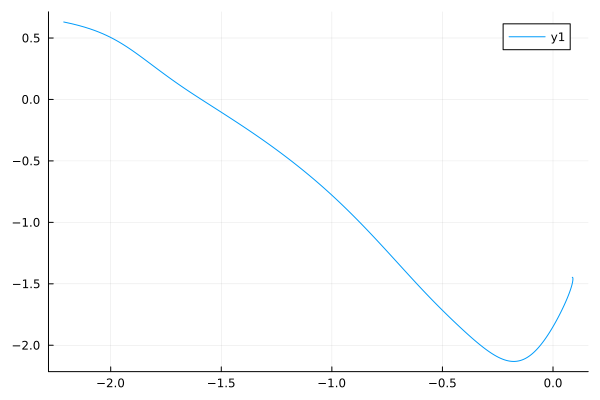

In [501]:
matrix = UniversalDiffEq.forecast(model,[-0.75,2.0], 72.01, collect(73:0.01:90))
Plots.plot(matrix[:,2],matrix[:,3])

In [502]:

using ForwardDiff


function transform_dynamics(u,mean,scale)
    y = scale.*exp.(u).+mean
    return y
end


function percap_growth(y,mean,scale,rhs)
    u = log.((y.-mean)./scale)
    X = u[3:end]; u = u[1:2]
    dy_percap = scale[1:2].*rhs(u,X,0.0)
    return  dy_percap
end 


function percap_growth_jacobian(y,mean,scale,rhs)
    f = y ->  percap_growth(y,mean,scale,rhs)
    return ForwardDiff.jacobian(f, y)
end 


function get_scaling_factors(site)
    scaling_factors  = CSV.read("../data/scaling_factors.csv", DataFrame)[:,2:end]
    scaling_factors = scaling_factors[scaling_factors.SITE.==site,:]
    Xinds = [4,6,2,3]
    mean = scaling_factors.mean[Xinds]
    scale = scaling_factors.sd[Xinds]
    return scale, mean
end

rhs = UniversalDiffEq.get_right_hand_side(model)

scale, means = get_scaling_factors(4)
obs = size(model.parameters.uhat)[2]
effects_juv = zeros(obs,4)
effects_adults = zeros(obs,4)
for i in 1:size(model.parameters.uhat)[2]
    u = vcat(model.parameters.uhat[:,i],Vector(model.X[i,2:end]))
    y = transform_dynamics(u,means,scale)
    effects = percap_growth_jacobian(y,means,scale,rhs)
    effects_juv[i,:] = effects[1,:]
    effects_adults[i,:] = effects[2,:]
end 



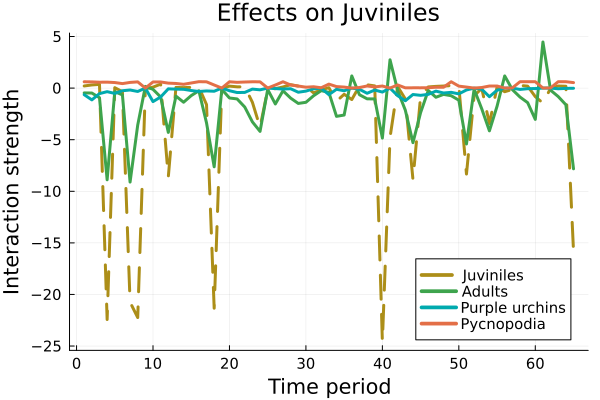

In [503]:
Plots.plot(effects_juv[:,1], width = 3,  label = "Juviniles",c=5,linestyle=:dash)
Plots.plot!(effects_juv[:,2], width = 3,  label = "Adults",c=3)
Plots.plot!(effects_juv[:,3], width = 3, label = "Purple urchins",c=6)
Plots.plot!(effects_juv[:,4], width = 3, label = "Pycnopodia",c=2)
Plots.plot!(tickfontsize=10, legendfontsize=10, guidefontsize=14,titlefontsize=16,
            xlabel = "Time period",ylabel = "Interaction strength",
            title = "Effects on Juviniles")

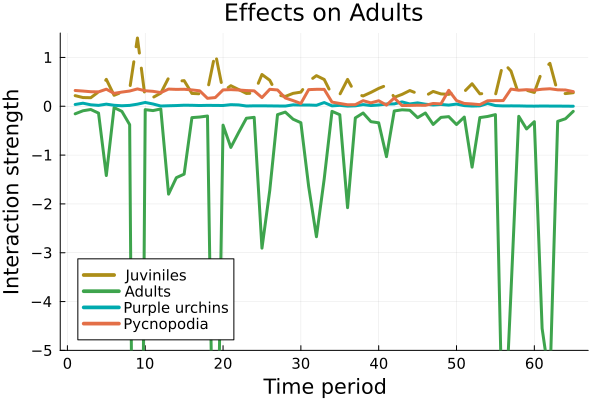

In [504]:
Plots.plot(effects_adults[:,1], width = 3,  label = "Juviniles",c=5,linestyle=:dash)
Plots.plot!(effects_adults[:,2], width = 3,  label = "Adults",c=3)
Plots.plot!(effects_adults[:,3], width = 3, label = "Purple urchins",c=6)
Plots.plot!(effects_adults[:,4], width = 3, label = "Pycnopodia",c=2)
Plots.plot!(tickfontsize=10, legendfontsize=10, guidefontsize=14,titlefontsize=16,
            xlabel = "Time period",ylabel = "Interaction strength",
            title = "Effects on Adults", ylims = (-5.0,1.5))

In [505]:
maximum(effects_adults)

1.3976552308541657

1234

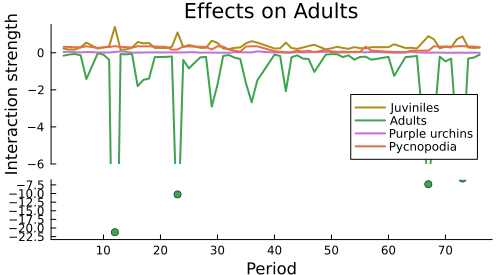

In [506]:
using Plots.PlotMeasures
function breakplot(X, Y, yb,col; lc=:blue, ylabel="Interaction strength",
                    title="Effect on Adults", ptheme=:default, labels = repeat([""], size(X)[2]))
                    
    # yb is a vector of tuples for breaks, e.g., [(100, 300)]
    # This example assumes one break for simplicity
    yl_bottom = (minimum(Y)*1.1, yb[1][1])
    yl_top = (yb[1][2], maximum(Y)*1.1)
    
    # Create layout: top plot (outliers) and bottom plot (main data)
    l = @layout [a{0.7h}; b{0.3h}] # adjust heights
    
    # Bottom plot
    p1 = plot(); p2 = plot()
    for i in 1:size(X)[2]
        print(i)
        scatter!(p1,X[:,i], Y[:,i], ylims=yl_bottom, framestyle=:default, legend=false, 
                margin=0mm, c=col[i], ylabel = "", xlabel = "Period",label="")
        
        # Top plot
        plot!(p2,X[:,i], Y[:,i], ylims=yl_top, framestyle=:default,  
                margin=0mm, showaxis=:y, xticks=false,c=col[i], width = 2,
                ylabel = ylabel, title = title, label = labels[i],
                legendposition=:bottomright)

    end
    # Combine
    plot(p2, p1, layout=l, size=(500,275), grid=false)
end
col = [5,3,4,2]
X = reduce(hcat,repeat([dat_states.PERIOD],4))
Y = effects_adults
labels = ["Juviniles", "Adults","Purple urchins", "Pycnopodia"]
breakplot(X, Y, [(-6,-6.0)],col,title="Effects on Adults", 
        ylabel = "Interaction strength", labels = labels)

1234

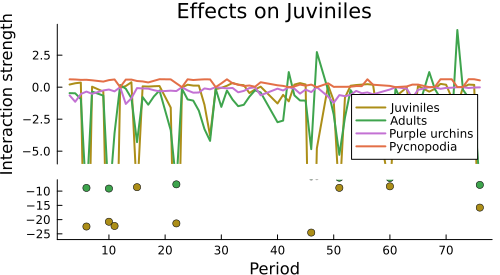

In [507]:
col = [5,3,4,2]
X = reduce(hcat,repeat([dat_states.PERIOD],4))
Y = effects_juv
breakplot(X, Y, [(-6,-6.0)],col,title="Effects on Juviniles", 
            ylabel = "Interaction strength", labels = labels)

In [508]:
adults_df = stack(DataFrame(effects_adults,[:Juv,:Adults,:Urchins,:Pyc]))
adults_df.outcome .= "Adults"
juv_df = stack(DataFrame(effects_juv,[:Juv,:Adults,:Urchins,:Pyc]))
juv_df.outcome .= "Juviniles"
effects_df = vcat(adults_df,juv_df)
effects_df[1:4,:]

Row,variable,value,outcome
,String,Float64,String
1,Juv,0.217564,Adults
2,Juv,0.178389,Adults
3,Juv,0.175119,Adults
4,Juv,0.294953,Adults


In [509]:
using StatsPlots
p1_ = @df adults_df boxplot(:variable, :value, ylim = (-6.25,2.0),ylabel = "Interaction strength",
                        label = "",  color = "white", width = 2, title = "Adults (UDE)")
p2_ = @df juv_df boxplot(:variable, :value, ylim = (-6.25,2.0),label = "", 
                         color = "white", width = 2,title = "Juviniles (UDE)")
plot(p1_,p2_)
p3 = Plots.plot!(tickfontsize=10, legendfontsize=8, guidefontsize=12,titlefontsize=12,
            xlabel = "Varaible", size = (600,250), margin = 5mm,dpi=600)
savefig("~/documents/site4_effects_box_node.png")

"/Users/johnbuckner/documents/site4_effects_box_node.png"